<a href="https://colab.research.google.com/github/anjineyulutv/Amazon_Fine_Food_Reviews/blob/master/HR_copilot_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

## Google Colab is available in VS Code!
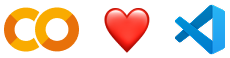

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

In [11]:
!pip install -q ipywidgets google-cloud-texttospeech google-cloud-speech reportlab
!jupyter nbextension enable --py widgetsnbextension --sys-prefix 2>/dev/null || true
print("✅ Done — NOW go to Runtime > Restart Session, then run from Cell 2")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.8 MB/s eta 0:00:00
✅ Done — NOW go to Runtime > Restart Session, then run from Cell 2


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "//content/drive/MyDrive/anjuedtechcopilot-b29b5ab38fcc.json"

In [13]:
import random
import uuid
import subprocess
import base64
import tempfile
import threading
import time
import numpy as np
from flask import Flask, request, jsonify, render_template_string, send_file
from flask_cors import CORS
from google.cloud import texttospeech, speech
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors

print("✅ All imports OK")

✅ All imports OK


In [14]:
tts_client    = texttospeech.TextToSpeechClient()
speech_client = speech.SpeechClient()
print("✅ TTS and STT clients ready")

✅ TTS and STT clients ready


In [15]:
def speak(text):
    try:
        synthesis_input = texttospeech.SynthesisInput(text=text)
        voice = texttospeech.VoiceSelectionParams(
            language_code="en-US",
            ssml_gender=texttospeech.SsmlVoiceGender.NEUTRAL
        )
        audio_config = texttospeech.AudioConfig(
            audio_encoding=texttospeech.AudioEncoding.MP3
        )
        response = tts_client.synthesize_speech(
            input=synthesis_input, voice=voice, audio_config=audio_config
        )
        filename = f"/tmp/{uuid.uuid4()}.mp3"
        with open(filename, "wb") as f:
            f.write(response.audio_content)
        return filename
    except Exception as e:
        print(f"TTS error: {e}")
        return None

print("✅ speak() ready")

✅ speak() ready


In [16]:
def transcribe(audio_path):
    if audio_path is None:
        return "No audio received."
    try:
        wav_path = f"/tmp/{uuid.uuid4()}.wav"
        subprocess.run(
            ["ffmpeg", "-y", "-i", audio_path,
             "-ar", "16000", "-ac", "1", "-f", "wav", wav_path],
            capture_output=True
        )
        with open(wav_path, "rb") as f:
            audio_bytes = f.read()

        audio  = speech.RecognitionAudio(content=audio_bytes)
        config = speech.RecognitionConfig(
            encoding=speech.RecognitionConfig.AudioEncoding.LINEAR16,
            sample_rate_hertz=16000,
            language_code="en-US"
        )
        response = speech_client.recognize(config=config, audio=audio)
        text = " ".join([r.alternatives[0].transcript for r in response.results])
        return text if text else "Could not detect speech clearly."
    except Exception as e:
        return f"[STT error: {str(e)[:80]}]"

print("✅ transcribe() ready")

✅ transcribe() ready


In [17]:
COURSE_KNOWLEDGE = [
    "Customer Acquisition Cost (CAC) vs Lifetime Value (LTV)",
    "Marketing funnel optimization",
    "Multi-touch attribution modeling",
    "A/B experimentation frameworks",
    "Growth metrics and KPI dashboards",
    "Budget allocation across marketing channels",
    "Brand vs performance marketing strategy",
    "Cohort analysis and retention modeling",
    "Campaign analytics and creative testing",
    "Growth strategy and GTM planning"
]

def build_dof_space():
    return [{"name": t, "weight": random.uniform(0.6, 1.0)} for t in COURSE_KNOWLEDGE]

DOF_SPACE = build_dof_space()

def select_dof():
    weights = np.array([d["weight"] for d in DOF_SPACE])
    probs   = np.random.dirichlet(weights)
    idx     = np.argmax(probs)
    entropy = -np.sum(probs * np.log(probs + 1e-9))
    return DOF_SPACE[idx], round(float(entropy), 3)

def generate_question():
    dof, entropy = select_dof()
    topic = dof["name"]
    templates = [
        f"A startup is struggling with {topic}. How would you diagnose and fix it?",
        f"Walk me through a framework to optimize {topic} in a growth-stage company.",
        f"What are the key trade-offs when prioritizing {topic} over other metrics?",
        f"Design a 30-day experiment to improve {topic}. What metrics would you track?",
        f"How would you explain {topic} to a non-technical founder?",
    ]
    return random.choice(templates), dof, entropy

def evaluate_answer(answer):
    depth     = random.uniform(6, 10)
    clarity   = random.uniform(6, 10)
    strategy  = random.uniform(6, 10)
    composite = round((depth + clarity + strategy) / 3, 2)
    feedback  = (
        f"Depth: {depth:.1f}/10 | Clarity: {clarity:.1f}/10 | "
        f"Strategy: {strategy:.1f}/10 — Composite: {composite}/10"
    )
    return composite, feedback

TOTAL_QUESTIONS = 10
print(f"✅ DOF space ready — {len(COURSE_KNOWLEDGE)} topics loaded")

✅ DOF space ready — 10 topics loaded


In [18]:
def generate_report(scores):
    if not scores:
        return None
    styles   = getSampleStyleSheet()
    filepath = "/tmp/interview_report.pdf"
    doc      = SimpleDocTemplate(filepath)
    elements = []

    elements.append(Paragraph("AI Interview Engine — Candidate Report", styles["Title"]))
    elements.append(Spacer(1, 20))

    avg = round(np.mean(scores), 2)
    elements.append(Paragraph(f"Questions Answered: {len(scores)}/10", styles["Normal"]))
    elements.append(Paragraph(f"Average Score: {avg}/10", styles["Normal"]))
    elements.append(Spacer(1, 16))

    table_data = [["Question #", "Score", "Rating"]]
    for i, s in enumerate(scores):
        rating = "Excellent" if s >= 9 else "Good" if s >= 7.5 else "Fair"
        table_data.append([str(i + 1), f"{s}/10", rating])

    table = Table(table_data, colWidths=[100, 100, 150])
    table.setStyle(TableStyle([
        ("BACKGROUND",     (0, 0), (-1, 0),  colors.HexColor("#1e1b4b")),
        ("TEXTCOLOR",      (0, 0), (-1, 0),  colors.white),
        ("FONTNAME",       (0, 0), (-1, 0),  "Helvetica-Bold"),
        ("GRID",           (0, 0), (-1, -1), 0.5, colors.grey),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#f5f5ff")]),
        ("ALIGN",          (0, 0), (-1, -1), "CENTER"),
        ("VALIGN",         (0, 0), (-1, -1), "MIDDLE"),
    ]))
    elements.append(table)
    elements.append(Spacer(1, 20))

    verdict = "Outstanding" if avg >= 9 else "Strong" if avg >= 7.5 else "Needs Improvement"
    elements.append(Paragraph(f"Overall Verdict: {verdict}", styles["Heading2"]))
    doc.build(elements)
    return filepath

print("✅ generate_report() ready")

✅ generate_report() ready


In [19]:
RECORD_JS = """
async function recordAudio(duration) {
    const stream = await navigator.mediaDevices.getUserMedia({audio: true});
    const recorder = new MediaRecorder(stream);
    const chunks = [];
    recorder.ondataavailable = e => chunks.push(e.data);
    recorder.start();
    await new Promise(r => setTimeout(r, duration * 1000));
    recorder.stop();
    await new Promise(r => recorder.onstop = r);
    stream.getTracks().forEach(t => t.stop());
    const blob = new Blob(chunks, {type: 'audio/webm'});
    const reader = new FileReader();
    reader.readAsDataURL(blob);
    await new Promise(r => reader.onloadend = r);
    return reader.result.split(',')[1];
}
"""

from google.colab import output as colab_output
import asyncio

def record_audio_colab(duration=10):
    """Records audio in Colab browser and returns path to saved webm file."""
    colab_output.register_callback('save_audio', lambda b64: None)

    result = {}

    def save_cb(b64_data):
        audio_bytes = base64.b64decode(b64_data)
        path = f"/tmp/{uuid.uuid4()}.webm"
        with open(path, 'wb') as f:
            f.write(audio_bytes)
        result['path'] = path

    colab_output.register_callback('save_audio', save_cb)

    from IPython.display import Javascript
    display(Javascript(f"""
    {RECORD_JS}
    (async () => {{
        document.querySelector('#record-status').textContent = '🔴 Recording for {duration}s...';
        const b64 = await recordAudio({duration});
        google.colab.kernel.invokeFunction('save_audio', [b64], {{}});
        document.querySelector('#record-status').textContent = '✅ Recording done — processing...';
    }})();
    """))

    timeout = duration + 5
    start   = time.time()
    while 'path' not in result and time.time() - start < timeout:
        time.sleep(0.5)

    return result.get('path', None)

print("✅ record_audio_colab() ready")

✅ record_audio_colab() ready


In [21]:
!pip install -q ipywidgets
import ipywidgets as widgets
from IPython.display import display, Audio, clear_output, HTML
import random, uuid, subprocess, base64, tempfile, time, numpy as np
from google.cloud import texttospeech, speech
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
print("✅ All imports OK")

✅ All imports OK


In [22]:
# ── State ────────────────────────────────────────────────────────────────────
state = {
    "index":  0,
    "scores": [],
    "done":   False,
}

# ── Widgets ──────────────────────────────────────────────────────────────────
header_html = widgets.HTML("""
<div style="text-align:center; padding:24px;
            background:linear-gradient(135deg,#020617,#1e1b4b);
            border-radius:16px; margin-bottom:12px; color:white;">
    <div style="width:80px; height:80px; border-radius:50%; margin:0 auto 12px;
                background:radial-gradient(circle at 40% 40%,#818cf8,#1e1b4b);
                box-shadow:0 0 30px #6366f188;"></div>
    <h2 style="margin:0; font-size:1.8rem; color:#c7d2fe; letter-spacing:1px;">
        🧠 AI Interview Engine
    </h2>
    <p style="color:#a5b4fc; margin:8px 0 0 0;">
        10 Questions · Voice Powered · AI Scored
    </p>
</div>
""")

progress_bar = widgets.IntProgress(
    value=0, min=0, max=10,
    description='Progress:',
    style={'bar_color': '#6366f1'},
    layout=widgets.Layout(width='100%', margin='8px 0')
)

chat_output = widgets.Output(
    layout=widgets.Layout(
        border='1px solid #334155',
        border_radius='12px',
        padding='16px',
        height='360px',
        overflow_y='auto',
        background_color='#0f172a',
        margin='8px 0'
    )
)

record_duration = widgets.IntSlider(
    value=15, min=5, max=60, step=5,
    description='Rec (sec):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='320px')
)

status_label = widgets.HTML(
    value='<p id="record-status" style="color:#a5b4fc; text-align:center; '
          'font-size:0.95rem; margin:6px 0;">Click Start Interview to begin</p>'
)

audio_output = widgets.Output(layout=widgets.Layout(margin='6px 0'))

start_btn  = widgets.Button(
    description='🎙️ Start Interview',
    button_style='primary',
    layout=widgets.Layout(width='200px', height='44px')
)
record_btn = widgets.Button(
    description='🎤 Record Answer',
    button_style='success',
    disabled=True,
    layout=widgets.Layout(width='200px', height='44px')
)
report_btn = widgets.Button(
    description='📄 Download Report',
    button_style='warning',
    disabled=True,
    layout=widgets.Layout(width='200px', height='44px')
)

btn_row = widgets.HBox(
    [start_btn, record_btn, report_btn],
    layout=widgets.Layout(justify_content='center', gap='12px', margin='8px 0')
)

# ── Helpers ───────────────────────────────────────────────────────────────────
def add_message(text, role='bot'):
    color  = '#818cf8' if role == 'bot' else '#94a3b8'
    label  = '🤖 Interviewer' if role == 'bot' else '🎤 You'
    bubble_bg = 'rgba(99,102,241,0.2)' if role == 'bot' else 'rgba(255,255,255,0.08)'
    align  = 'left' if role == 'bot' else 'right'
    with chat_output:
        display(HTML(f"""
        <div style="margin:8px 0; text-align:{align};">
            <div style="font-size:0.72rem; color:{color}; margin-bottom:3px;">{label}</div>
            <div style="display:inline-block; max-width:85%;
                        background:{bubble_bg}; border-radius:12px;
                        padding:10px 14px; color:white;
                        font-size:0.9rem; line-height:1.5;
                        white-space:pre-wrap; text-align:left;">
                {text}
            </div>
        </div>
        """))

def set_status(msg):
    status_label.value = (
        f'<p id="record-status" style="color:#a5b4fc; text-align:center; '
        f'font-size:0.95rem; margin:6px 0;">{msg}</p>'
    )

def play_tts(audio_path):
    if not audio_path:
        return
    with audio_output:
        clear_output(wait=True)
        display(Audio(audio_path, autoplay=True))

# ── Button Handlers ───────────────────────────────────────────────────────────
def on_start(b):
    state["index"]  = 1
    state["scores"] = []
    state["done"]   = False

    with chat_output:
        clear_output()

    q, dof, entropy = generate_question()
    state["current_dof"] = dof["name"]

    intro = (
        "👋 Welcome to the AI Marketing Interview!\n\n"
        "I'll ask you 10 questions. Use the Record button to speak your answer.\n\n"
        f"❓ Question 1:\n{q}"
    )
    add_message(intro, 'bot')
    progress_bar.value = 0
    set_status("Ready — click Record Answer to speak")

    start_btn.disabled  = True
    record_btn.disabled = False
    report_btn.disabled = True

    audio_path = speak(f"Welcome! Here is Question 1. {q}")
    play_tts(audio_path)


def on_record(b):
    if state["done"]:
        return

    record_btn.disabled = True
    set_status(f"🔴 Recording for {record_duration.value} seconds... speak now!")

    audio_path = record_audio_colab(duration=record_duration.value)
    set_status("⏳ Transcribing...")

    transcription = transcribe(audio_path)
    add_message(transcription, 'user')

    score, feedback = evaluate_answer(transcription)
    state["scores"].append(score)
    add_message(f"📊 {feedback}", 'bot')

    state["index"] += 1
    progress_bar.value = state["index"] - 1

    if state["index"] > TOTAL_QUESTIONS:
        avg     = round(float(np.mean(state["scores"])), 2)
        verdict = "Outstanding" if avg >= 9 else "Strong" if avg >= 7.5 else "Good effort"
        add_message(
            f"✅ Interview Complete!\n\n"
            f"🏆 Final Score: {avg}/10 — {verdict}\n\n"
            f"Click Download Report for your PDF.",
            'bot'
        )
        state["done"]       = True
        record_btn.disabled = True
        report_btn.disabled = False
        set_status("✅ Done! Click Download Report.")
        audio_path = speak(f"Interview complete! Your score is {avg} out of 10. {verdict}!")
        play_tts(audio_path)
    else:
        q, dof, entropy      = generate_question()
        state["current_dof"] = dof["name"]
        q_num                = state["index"]
        add_message(f"❓ Question {q_num}:\n{q}", 'bot')
        set_status("Ready — click Record Answer to speak")
        record_btn.disabled = False
        audio_path = speak(f"Question {q_num}. {q}")
        play_tts(audio_path)


def on_report(b):
    set_status("⏳ Generating PDF report...")
    pdf_path = generate_report(state["scores"])
    if pdf_path:
        from google.colab import files
        files.download(pdf_path)
        set_status("✅ Report downloaded!")
    else:
        set_status("❌ No scores to report yet.")


start_btn.on_click(on_start)
record_btn.on_click(on_record)
report_btn.on_click(on_report)

# ── Layout + Display ──────────────────────────────────────────────────────────
ui = widgets.VBox([
    header_html,
    progress_bar,
    chat_output,
    audio_output,
    status_label,
    record_duration,
    btn_row,
], layout=widgets.Layout(
    max_width='780px',
    margin='0 auto',
    padding='16px'
))

display(ui)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# ── State ────────────────────────────────────────────────────────────────────
state = {
    "index":  0,
    "scores": [],
    "done":   False,
}

# ── Widgets ──────────────────────────────────────────────────────────────────
header_html = widgets.HTML("""
<div style="text-align:center; padding:24px;
            background:linear-gradient(135deg,#020617,#1e1b4b);
            border-radius:16px; margin-bottom:12px; color:white;">
    <div style="width:80px; height:80px; border-radius:50%; margin:0 auto 12px;
                background:radial-gradient(circle at 40% 40%,#818cf8,#1e1b4b);
                box-shadow:0 0 30px #6366f188;"></div>
    <h2 style="margin:0; font-size:1.8rem; color:#c7d2fe; letter-spacing:1px;">
        🧠 AI Interview Engine
    </h2>
    <p style="color:#a5b4fc; margin:8px 0 0 0;">
        Voice Powered · AI Scored · Configurable
    </p>
</div>
""")

# ── Config Row ────────────────────────────────────────────────────────────────
total_q_slider = widgets.IntSlider(
    value=10, min=1, max=20, step=1,
    description='Questions:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='340px')
)

record_duration = widgets.IntSlider(
    value=15, min=5, max=60, step=5,
    description='Rec (sec):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='340px')
)

config_box = widgets.VBox([
    widgets.HTML('<p style="color:#a5b4fc; font-size:0.85rem; margin:4px 0;">⚙️ Configure before starting:</p>'),
    total_q_slider,
    record_duration,
], layout=widgets.Layout(
    background_color='rgba(255,255,255,0.03)',
    border='1px solid #334155',
    border_radius='10px',
    padding='12px',
    margin='6px 0'
))

progress_bar = widgets.IntProgress(
    value=0, min=0, max=10,
    description='Progress:',
    style={'bar_color': '#6366f1'},
    layout=widgets.Layout(width='100%', margin='8px 0')
)

chat_output = widgets.Output(
    layout=widgets.Layout(
        border='1px solid #334155',
        border_radius='12px',
        padding='16px',
        height='360px',
        overflow_y='auto',
        background_color='#0f172a',
        margin='8px 0'
    )
)

# Countdown timer display
timer_html = widgets.HTML(
    value='',
    layout=widgets.Layout(margin='4px 0')
)

status_label = widgets.HTML(
    value='<p id="record-status" style="color:#a5b4fc; text-align:center; '
          'font-size:0.95rem; margin:6px 0;">Configure settings, then click Start Interview</p>'
)

audio_output = widgets.Output(layout=widgets.Layout(margin='6px 0'))

start_btn  = widgets.Button(
    description='🎙️ Start Interview',
    button_style='primary',
    layout=widgets.Layout(width='200px', height='44px')
)
record_btn = widgets.Button(
    description='🎤 Record Answer',
    button_style='success',
    disabled=True,
    layout=widgets.Layout(width='200px', height='44px')
)
report_btn = widgets.Button(
    description='📄 Download Report',
    button_style='warning',
    disabled=True,
    layout=widgets.Layout(width='200px', height='44px')
)

btn_row = widgets.HBox(
    [start_btn, record_btn, report_btn],
    layout=widgets.Layout(justify_content='center', gap='12px', margin='8px 0')
)

# ── Helpers ───────────────────────────────────────────────────────────────────
def add_message(text, role='bot'):
    color     = '#818cf8' if role == 'bot' else '#94a3b8'
    label     = '🤖 Interviewer' if role == 'bot' else '🎤 You'
    bubble_bg = 'rgba(99,102,241,0.2)' if role == 'bot' else 'rgba(255,255,255,0.08)'
    align     = 'left' if role == 'bot' else 'right'
    with chat_output:
        display(HTML(f"""
        <div style="margin:8px 0; text-align:{align};">
            <div style="font-size:0.72rem; color:{color}; margin-bottom:3px;">{label}</div>
            <div style="display:inline-block; max-width:85%;
                        background:{bubble_bg}; border-radius:12px;
                        padding:10px 14px; color:white;
                        font-size:0.9rem; line-height:1.5;
                        white-space:pre-wrap; text-align:left;">
                {text}
            </div>
        </div>
        """))

def set_status(msg):
    status_label.value = (
        f'<p id="record-status" style="color:#a5b4fc; text-align:center; '
        f'font-size:0.95rem; margin:6px 0;">{msg}</p>'
    )

def play_tts(audio_path):
    if not audio_path:
        return
    with audio_output:
        clear_output(wait=True)
        display(Audio(audio_path, autoplay=True))

def show_timer(seconds):
    """Runs countdown timer in a background thread, updating timer_html every second."""
    def _countdown():
        for remaining in range(seconds, 0, -1):
            pct        = (remaining / seconds) * 100
            bar_color  = '#10b981' if pct > 50 else '#f59e0b' if pct > 25 else '#ef4444'
            timer_html.value = f"""
            <div style="text-align:center; margin:6px 0;">
                <div style="font-size:2rem; font-weight:bold; color:{bar_color};
                            font-family:monospace; letter-spacing:2px;">
                    ⏱ {remaining}s
                </div>
                <div style="background:rgba(255,255,255,0.1); border-radius:99px;
                            height:8px; width:100%; margin-top:6px; overflow:hidden;">
                    <div style="background:{bar_color}; height:100%;
                                width:{pct}%; border-radius:99px;
                                transition:width 0.9s ease;"></div>
                </div>
            </div>
            """
            time.sleep(1)
        timer_html.value = '<div style="text-align:center; color:#ef4444; font-size:1rem;">⏹️ Time up!</div>'

    threading.Thread(target=_countdown, daemon=True).start()

# ── Button Handlers ───────────────────────────────────────────────────────────
def on_start(b):
    total = total_q_slider.value
    state["index"]         = 1
    state["scores"]        = []
    state["done"]          = False
    state["total"]         = total
    progress_bar.max       = total
    progress_bar.value     = 0

    # Lock config sliders once started
    total_q_slider.disabled = True
    record_duration.disabled = True

    with chat_output:
        clear_output()

    q, dof, entropy      = generate_question()
    state["current_dof"] = dof["name"]

    intro = (
        f"👋 Welcome to the AI Marketing Interview!\n\n"
        f"You will be asked {total} questions. "
        f"Click Record Answer and speak clearly.\n\n"
        f"❓ Question 1:\n{q}"
    )
    add_message(intro, 'bot')
    set_status("Ready — click Record Answer to speak")

    start_btn.disabled  = True
    record_btn.disabled = False
    report_btn.disabled = True
    timer_html.value    = ''

    audio_path = speak(f"Welcome! Here is Question 1. {q}")
    play_tts(audio_path)


def on_record(b):
    if state["done"]:
        return

    duration = record_duration.value
    record_btn.disabled = True
    set_status(f"🔴 Recording — speak your answer!")

    # Start countdown timer visually
    show_timer(duration)

    # Record audio (blocks for duration seconds)
    audio_path = record_audio_colab(duration=duration)

    timer_html.value = ''
    set_status("⏳ Transcribing your answer...")

    transcription = transcribe(audio_path)
    add_message(transcription, 'user')

    score, feedback = evaluate_answer(transcription)
    state["scores"].append(score)
    add_message(f"📊 {feedback}", 'bot')

    state["index"]     += 1
    total               = state["total"]
    progress_bar.value  = state["index"] - 1

    if state["index"] > total:
        avg     = round(float(np.mean(state["scores"])), 2)
        verdict = "Outstanding" if avg >= 9 else "Strong" if avg >= 7.5 else "Good effort"
        add_message(
            f"✅ Interview Complete!\n\n"
            f"🏆 Final Score: {avg}/10 — {verdict}\n\n"
            f"Click Download Report for your PDF.",
            'bot'
        )
        state["done"]            = True
        record_btn.disabled      = True
        report_btn.disabled      = False
        total_q_slider.disabled  = False
        record_duration.disabled = False
        set_status("✅ Done! Click Download Report.")
        audio_path = speak(f"Interview complete! Your score is {avg} out of 10. {verdict}!")
        play_tts(audio_path)
    else:
        q, dof, entropy      = generate_question()
        state["current_dof"] = dof["name"]
        q_num                = state["index"]
        add_message(f"❓ Question {q_num}:\n{q}", 'bot')
        set_status("Ready — click Record Answer to speak")
        record_btn.disabled = False
        audio_path = speak(f"Question {q_num}. {q}")
        play_tts(audio_path)


def on_report(b):
    set_status("⏳ Generating PDF report...")
    pdf_path = generate_report(state["scores"])
    if pdf_path:
        from google.colab import files
        files.download(pdf_path)
        set_status("✅ Report downloaded!")
    else:
        set_status("❌ No scores to report yet.")


start_btn.on_click(on_start)
record_btn.on_click(on_record)
report_btn.on_click(on_report)

# ── Layout + Display ──────────────────────────────────────────────────────────
ui = widgets.VBox([
    header_html,
    config_box,
    progress_bar,
    chat_output,
    audio_output,
    timer_html,
    status_label,
    btn_row,
], layout=widgets.Layout(
    max_width='780px',
    margin='0 auto',
    padding='16px'
))

display(ui)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import threading, time, uuid, base64, os
import ipywidgets as widgets
from IPython.display import display, Audio, clear_output, HTML
import numpy as np

# Inject CSS animation globally into the notebook output
display(HTML("""
<style>
@keyframes bubblePulse {
    0%   { box-shadow: 0 0 15px #6366f1aa; transform: scale(1);    }
    50%  { box-shadow: 0 0 40px #818cf8ff; transform: scale(1.12); }
    100% { box-shadow: 0 0 15px #6366f1aa; transform: scale(1);    }
}
@keyframes speakPulse {
    0%   { box-shadow: 0 0 20px #10b981aa; transform: scale(1);    }
    50%  { box-shadow: 0 0 50px #10b981ff; transform: scale(1.18); }
    100% { box-shadow: 0 0 20px #10b981aa; transform: scale(1);    }
}
@keyframes listenPulse {
    0%   { box-shadow: 0 0 20px #ef4444aa; transform: scale(1);    }
    50%  { box-shadow: 0 0 50px #ef4444ff; transform: scale(1.18); }
    100% { box-shadow: 0 0 20px #ef4444aa; transform: scale(1);    }
}
.avatar-idle    { animation: bubblePulse  2s infinite ease-in-out; }
.avatar-talking { animation: speakPulse  0.6s infinite ease-in-out; }
.avatar-listen  { animation: listenPulse 0.8s infinite ease-in-out; }
</style>
"""))

# ── State ─────────────────────────────────────────────────────────────────────
state = {
    "index":  0,
    "scores": [],
    "done":   False,
    "total":  10,
    "active": False,
}

# ── Avatar Widget (updateable) ────────────────────────────────────────────────
avatar_widget = widgets.HTML(value="")

def set_avatar(mode='idle', label='Waiting...'):
    """mode: idle | talking | listening"""
    colors_map = {
        'idle':      ('radial-gradient(circle at 40% 40%,#818cf8,#1e1b4b)', 'avatar-idle',    '#a5b4fc'),
        'talking':   ('radial-gradient(circle at 40% 40%,#10b981,#064e3b)', 'avatar-talking', '#6ee7b7'),
        'listening': ('radial-gradient(circle at 40% 40%,#ef4444,#7f1d1d)', 'avatar-listen',  '#fca5a5'),
        'thinking':  ('radial-gradient(circle at 40% 40%,#f59e0b,#78350f)', 'avatar-idle',    '#fcd34d'),
    }
    bg, css_class, text_color = colors_map.get(mode, colors_map['idle'])
    avatar_widget.value = f"""
    <div style="text-align:center; padding:20px 24px 10px;
                background:linear-gradient(135deg,#020617,#1e1b4b);
                border-radius:16px; margin-bottom:8px; color:white;">
        <div class="{css_class}"
             style="width:90px; height:90px; border-radius:50%;
                    background:{bg}; margin:0 auto 12px;">
        </div>
        <h2 style="margin:0; font-size:1.6rem; color:#c7d2fe; letter-spacing:1px;">
            🧠 AI Interview Engine
        </h2>
        <p style="color:{text_color}; margin:6px 0 0 0; font-size:0.95rem;">
            {label}
        </p>
    </div>
    """

# Initialize avatar
set_avatar('idle', 'Configure and click Start')

# ── Config ────────────────────────────────────────────────────────────────────
total_q_slider = widgets.IntSlider(
    value=10, min=1, max=20, step=1,
    description='Questions:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='340px')
)
record_duration = widgets.IntSlider(
    value=15, min=5, max=60, step=5,
    description='Answer (sec):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='340px')
)
config_box = widgets.VBox([
    widgets.HTML('<p style="color:#a5b4fc; font-size:0.85rem; margin:4px 0;">⚙️ Configure before starting:</p>'),
    total_q_slider,
    record_duration,
], layout=widgets.Layout(
    border='1px solid #334155',
    border_radius='10px',
    padding='12px',
    margin='4px 0'
))

# ── Progress ──────────────────────────────────────────────────────────────────
progress_bar = widgets.IntProgress(
    value=0, min=0, max=10,
    description='Progress:',
    style={'bar_color': '#6366f1'},
    layout=widgets.Layout(width='100%', margin='6px 0')
)

# ── Chat ──────────────────────────────────────────────────────────────────────
chat_output = widgets.Output(
    layout=widgets.Layout(
        border='1px solid #334155',
        border_radius='12px',
        padding='16px',
        height='340px',
        overflow_y='auto',
        background_color='#0f172a',
        margin='6px 0'
    )
)

# ── Audio ─────────────────────────────────────────────────────────────────────
audio_output = widgets.Output(
    layout=widgets.Layout(margin='2px 0', height='50px')
)

# ── Timer ─────────────────────────────────────────────────────────────────────
timer_html = widgets.HTML(value='')

# ── Buttons ───────────────────────────────────────────────────────────────────
start_btn = widgets.Button(
    description='🎙️ Start Interview',
    button_style='primary',
    layout=widgets.Layout(width='210px', height='46px')
)
stop_btn = widgets.Button(
    description='⏹️ Stop',
    button_style='danger',
    disabled=True,
    layout=widgets.Layout(width='120px', height='46px')
)
report_btn = widgets.Button(
    description='📄 Download Report',
    button_style='warning',
    disabled=True,
    layout=widgets.Layout(width='210px', height='46px')
)
btn_row = widgets.HBox(
    [start_btn, stop_btn, report_btn],
    layout=widgets.Layout(justify_content='center', gap='10px', margin='8px 0')
)

# ── Helpers ───────────────────────────────────────────────────────────────────
def add_message(text, role='bot'):
    color     = '#818cf8' if role == 'bot' else '#94a3b8'
    label     = '🤖 Interviewer' if role == 'bot' else '🎤 You'
    bubble_bg = 'rgba(99,102,241,0.2)' if role == 'bot' else 'rgba(255,255,255,0.08)'
    align     = 'left' if role == 'bot' else 'right'
    with chat_output:
        display(HTML(f"""
        <div style="margin:10px 0; text-align:{align};">
            <div style="font-size:0.72rem; color:{color}; margin-bottom:3px;">{label}</div>
            <div style="display:inline-block; max-width:85%;
                        background:{bubble_bg}; border-radius:12px;
                        padding:10px 14px; color:white; font-size:0.9rem;
                        line-height:1.6; white-space:pre-wrap; text-align:left;">
                {text}
            </div>
        </div>
        """))

def show_timer(seconds):
    def _countdown():
        for remaining in range(seconds, 0, -1):
            if not state["active"]:
                break
            pct       = (remaining / seconds) * 100
            bar_color = '#10b981' if pct > 50 else '#f59e0b' if pct > 25 else '#ef4444'
            timer_html.value = f"""
            <div style="text-align:center; margin:4px 0;">
                <div style="font-size:2.2rem; font-weight:bold;
                            color:{bar_color}; font-family:monospace;">
                    ⏱ {remaining}s
                </div>
                <div style="background:rgba(255,255,255,0.1); border-radius:99px;
                            height:10px; width:100%; margin-top:4px; overflow:hidden;">
                    <div style="background:{bar_color}; height:100%;
                                width:{pct}%; border-radius:99px;"></div>
                </div>
            </div>
            """
            time.sleep(1)
        timer_html.value = ''
    threading.Thread(target=_countdown, daemon=True).start()

def play_tts(text):
    """Speak text, display audio widget, wait for estimated playback to finish."""
    if not state["active"]:
        return
    audio_path = speak(text)
    if not audio_path:
        time.sleep(1)
        return
    try:
        size_kb  = os.path.getsize(audio_path) / 1024
        wait_sec = max(2, size_kb / 16)
    except Exception:
        wait_sec = 3
    with audio_output:
        clear_output(wait=True)
        display(Audio(audio_path, autoplay=True))
    time.sleep(wait_sec)

# ── Main Interview Loop ───────────────────────────────────────────────────────
def run_interview():
    total    = state["total"]
    duration = record_duration.value

    # ── Welcome ───────────────────────────────────────────────────────────────
    set_avatar('talking', '🎙️ Speaking — listen carefully...')
    welcome = (
        f"👋 Welcome to the AI Marketing Interview!\n\n"
        f"I will ask you {total} questions. After each question, "
        f"recording starts automatically — just speak your answer clearly!\n\n"
        f"Let's begin! 🚀"
    )
    add_message(welcome, 'bot')
    play_tts(f"Welcome! I will ask you {total} questions. "
             f"Recording starts automatically after each one. Let's begin!")

    # ── Question Loop ─────────────────────────────────────────────────────────
    for q_num in range(1, total + 1):
        if not state["active"]:
            break

        # Phase 1 — Bubble talks
        set_avatar('talking', f'🎙️ Question {q_num} of {total} — Listen...')
        q, dof, _ = generate_question()
        state["current_dof"] = dof["name"]

        add_message(f"❓ Question {q_num}:\n{q}", 'bot')
        play_tts(f"Question {q_num}. {q}")

        if not state["active"]:
            break

        # Phase 2 — You respond
        set_avatar('listening', f'🎤 Your turn — {duration}s to answer!')
        show_timer(duration)
        audio_path = record_audio_colab(duration=duration)

        # Phase 3 — Thinking
        set_avatar('thinking', '💭 Processing your answer...')
        timer_html.value = ''
        transcription = transcribe(audio_path)
        add_message(transcription, 'user')

        # Phase 4 — Score
        score, feedback = evaluate_answer(transcription)
        state["scores"].append(score)
        add_message(f"📊 {feedback}", 'bot')
        progress_bar.value = q_num

        # Brief pause then next question
        if q_num < total and state["active"]:
            set_avatar('idle', '⏸️ Next question in 2 seconds...')
            time.sleep(2)

    # ── Finish ────────────────────────────────────────────────────────────────
    if state["scores"] and state["active"]:
        avg     = round(float(np.mean(state["scores"])), 2)
        verdict = "Outstanding" if avg >= 9 else "Strong" if avg >= 7.5 else "Good effort"
        finish_msg = (
            f"✅ Interview Complete!\n\n"
            f"🏆 Final Score: {avg}/10 — {verdict}\n\n"
            f"Click Download Report for your PDF."
        )
        add_message(finish_msg, 'bot')
        set_avatar('talking', f'🏆 Score: {avg}/10 — {verdict}')
        play_tts(f"Interview complete! Your final score is {avg} out of 10. {verdict}!")

    set_avatar('idle', '✅ Interview finished — download your report!')
    state["active"]          = False
    start_btn.disabled       = False
    stop_btn.disabled        = True
    report_btn.disabled      = False
    total_q_slider.disabled  = False
    record_duration.disabled = False

# ── Button Handlers ───────────────────────────────────────────────────────────
def on_start(b):
    state.update({
        "index":  0,
        "scores": [],
        "done":   False,
        "active": True,
        "total":  total_q_slider.value,
    })
    progress_bar.max         = state["total"]
    progress_bar.value       = 0
    total_q_slider.disabled  = True
    record_duration.disabled = True
    start_btn.disabled       = True
    stop_btn.disabled        = False
    report_btn.disabled      = True
    timer_html.value         = ''
    with chat_output:
        clear_output()
    threading.Thread(target=run_interview, daemon=True).start()

def on_stop(b):
    state["active"]          = False
    set_avatar('idle', '⏹️ Interview stopped')
    stop_btn.disabled        = True
    start_btn.disabled       = False
    report_btn.disabled      = len(state["scores"]) == 0
    total_q_slider.disabled  = False
    record_duration.disabled = False
    timer_html.value         = ''

def on_report(b):
    set_avatar('thinking', '⏳ Generating PDF...')
    pdf_path = generate_report(state["scores"])
    if pdf_path:
        from google.colab import files
        files.download(pdf_path)
        set_avatar('idle', '✅ Report downloaded!')
    else:
        set_avatar('idle', '❌ No scores yet')

start_btn.on_click(on_start)
stop_btn.on_click(on_stop)
report_btn.on_click(on_report)

# ── Layout ────────────────────────────────────────────────────────────────────
ui = widgets.VBox([
    avatar_widget,
    config_box,
    progress_bar,
    chat_output,
    audio_output,
    timer_html,
    btn_row,
], layout=widgets.Layout(
    max_width='760px',
    margin='0 auto',
    padding='12px'
))

display(ui)